# *Sales and Profit Analysis Across Regions and Categories*

--- 

###  Loading Necessary Libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Loading Dataset

In [3]:
pd.set_option('display.max_columns', None)
df = pd.read_csv('Sample - Superstore.csv', encoding='latin-1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


### Familiriazing with a Dataset

In [4]:
df.shape # Check the number of rows and columns in the DataFrame

(9994, 21)

In [5]:
df.size # Total number of elements in the DataFrame (rows * columns)

209874

In [6]:
df.describe() # Get summary statistics for numerical columns

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [7]:
df.info() # Check data types and non-null counts

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [8]:
df.isnull().sum() # Check for missing values in each column

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [9]:
df.duplicated().sum() # Check for duplicate rows

0

### Data Handling

In [10]:
df[['Order Date', 'Ship Date']] = df[['Order Date', 'Ship Date']].apply(pd.to_datetime) # Convert 'Order Date' and 'Ship Date' to datetime format
df[['Order Date', 'Ship Date']].dtypes # Verify the data types of 'Order Date' and 'Ship Date' columns

Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object

In [11]:
df['Days_to_Ship'] = (df['Ship Date'] - df['Order Date']).dt.days # Create a new column 'Days_to_Ship' to calculate the number of days between order and ship dates
df.head() # Display the first few rows of the DataFrame to verify the new column

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Days_to_Ship
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,3
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,3
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,4
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,7
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,7


## *Total Sales and Profit by Region*

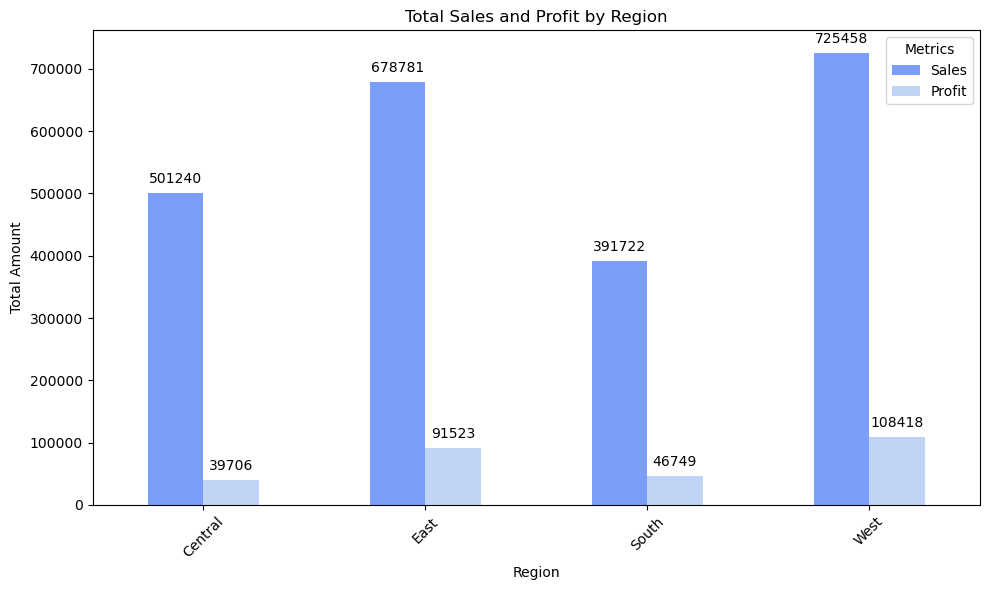

In [53]:
Sum_of_Sales_Profit_by_Region = df.groupby('Region').agg({'Sales':'sum', 'Profit': 'sum'}) # Group by 'Region' and calculate total sales and profit for each region
ax = Sum_of_Sales_Profit_by_Region.plot(kind='bar', figsize=(10, 6), color=sns.color_palette('coolwarm', len(Sum_of_Sales_Profit_by_Region))) # Create a bar plot to visualize total sales and profit by region
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.0f'), #Adding annotations to the bars to show the exact count of orders for each country
                (p.get_x() + p.get_width() / 2., p.get_height()), # Positioning the annotations at the center of each bar
                ha='center', va='center', 
                xytext=(0, 10), 
                textcoords='offset points')
plt.title('Total Sales and Profit by Region') # Set the title of the plot
plt.xlabel('Region') # Set the x-axis label         
plt.ylabel('Total Amount') # Set the y-axis label
plt.xticks(rotation=45) # Rotate x-axis labels for better readability
plt.legend(title='Metrics') # Add a legend with the title 'Metrics'
plt.tight_layout() # Adjust layout to prevent overlap
plt.show() # Display the plot


## *Total Sales and Profit by Category*

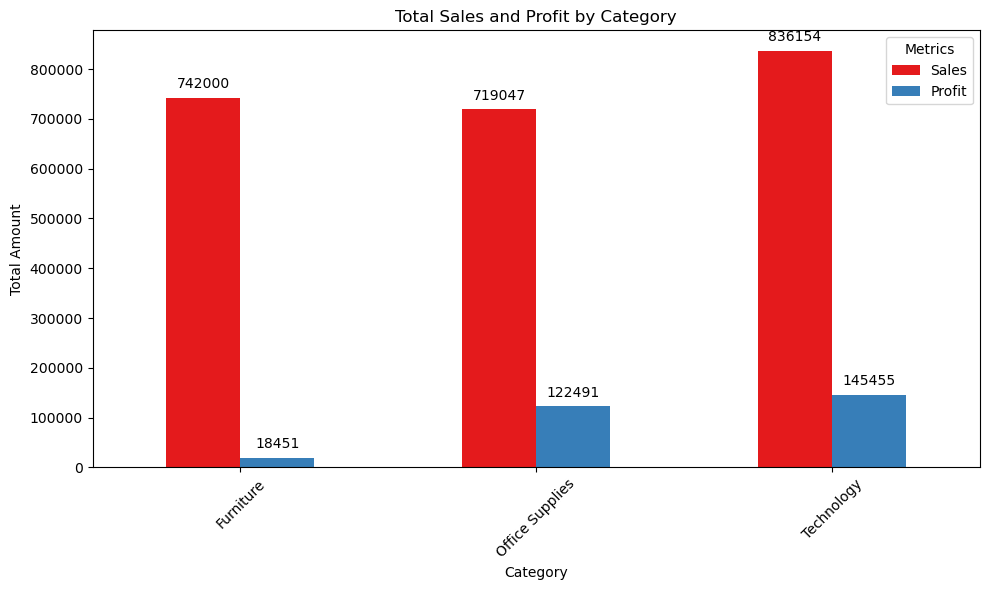

In [52]:
Sum_of_Sales_Profit_by_Category = df.groupby('Category').agg({'Sales':'sum', 'Profit': 'sum'}) # Group by 'Category' and calculate total sales and profit for each category
ax = Sum_of_Sales_Profit_by_Category.plot(kind='bar', figsize=(10, 6), color=sns.color_palette('Set1', len(Sum_of_Sales_Profit_by_Category))) # Create a bar plot to visualize total sales and profit by category
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.0f'), #Adding annotations to the bars to show the exact count of orders for each country
                (p.get_x() + p.get_width() / 2., p.get_height()), # Positioning the annotations at the center of each bar
                ha='center', va='center', 
                xytext=(0, 10), 
                textcoords='offset points')
plt.title('Total Sales and Profit by Category') # Set the title of the plot
plt.xlabel('Category') # Set the x-axis label
plt.ylabel('Total Amount') # Set the y-axis label
plt.xticks(rotation=45) # Rotate x-axis labels for better readability
plt.legend(title='Metrics') # Add a legend with the title 'Metrics'
plt.tight_layout() # Adjust layout to prevent overlap
plt.show() # Display the plot   

## *Total Sales & Profit by Sub-Category*

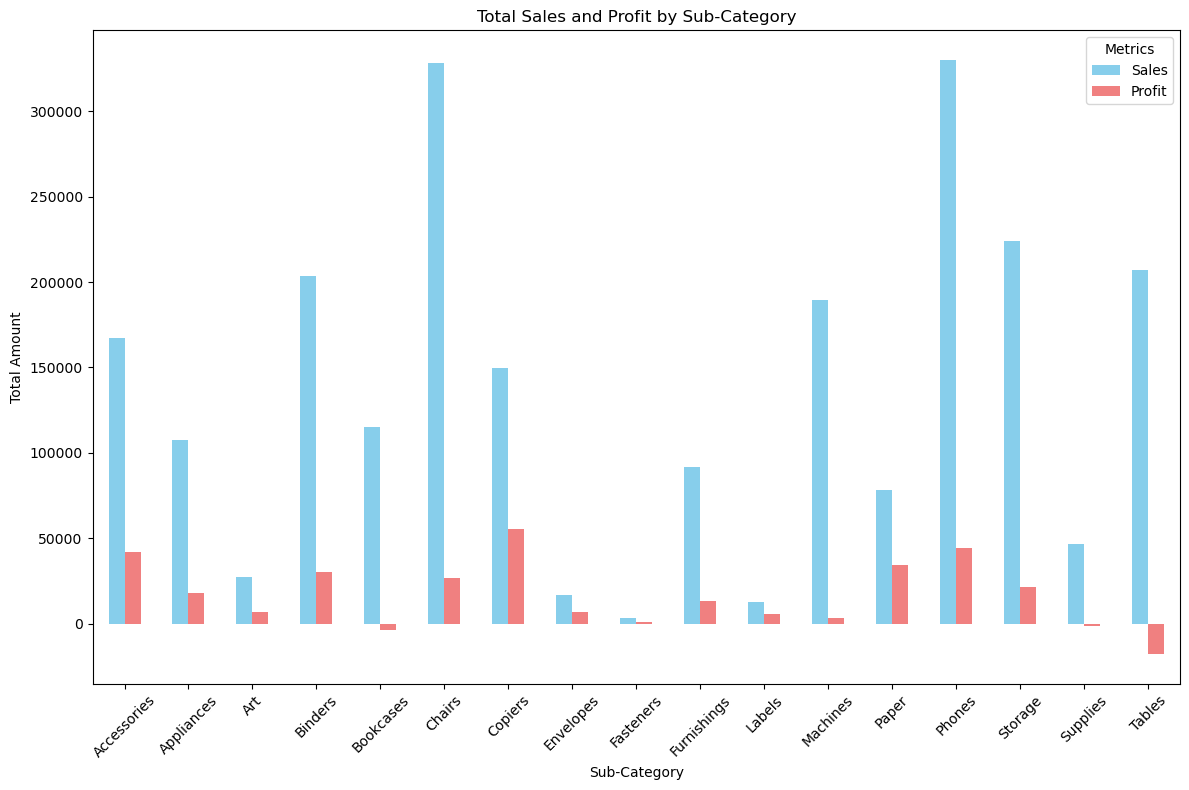

In [51]:
Sum_of_Sales_Profit_by_Sub_Category = df.groupby('Sub-Category').agg({'Sales':'sum', 'Profit': 'sum'}) # Group by 'Sub-Category' and calculate total sales and profit for each sub-category
Sum_of_Sales_Profit_by_Sub_Category.plot(kind='bar', figsize=(12, 8),color=['skyblue', 'lightcoral']) # Create a bar plot to visualize total sales and profit by sub-category
plt.title('Total Sales and Profit by Sub-Category') # Set the title of the plot 
plt.xlabel('Sub-Category') # Set the x-axis label
plt.ylabel('Total Amount') # Set the y-axis label
plt.xticks(rotation=45) # Rotate x-axis labels for better readability
plt.legend(title='Metrics') # Add a legend with the title 'Metrics'
plt.tight_layout() # Adjust layout to prevent overlap
plt.show() # Display the plot

### *Top 5 Sub-Categories by Profit*

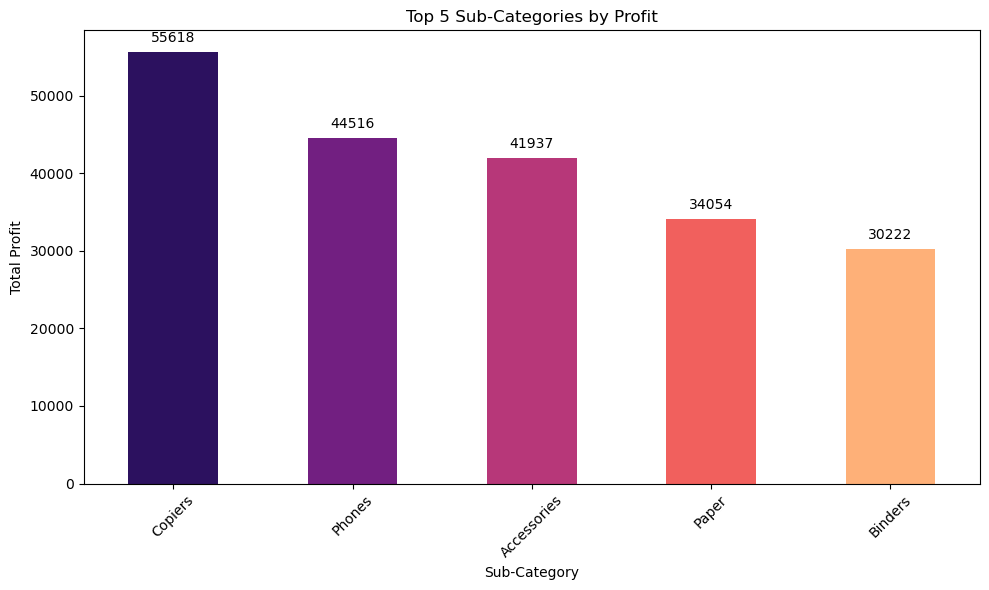

In [49]:
Top_5_sub_categories_by_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values(ascending=False).head(5) # Analyze profit by sub-category and sort in descending order, then select top 5
ax = Top_5_sub_categories_by_profit.plot(kind='bar', figsize=(10, 6), color=sns.color_palette('magma', len(Top_5_sub_categories_by_profit))) # Create a bar plot to visualize the top 5 sub-categories by profit
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.0f'), #Adding annotations to the bars to show the exact count of orders for each country
                (p.get_x() + p.get_width() / 2., p.get_height()), # Positioning the annotations at the center of each bar
                ha='center', va='center', 
                xytext=(0, 10), 
                textcoords='offset points')
plt.title('Top 5 Sub-Categories by Profit') # Set the title of the plot
plt.xlabel('Sub-Category') # Set the x-axis label
plt.ylabel('Total Profit') # Set the y-axis label
plt.xticks(rotation=45) # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent overlap
plt.show() # Display the plot


### *Bottom 5 Sub-Categories by Profit*

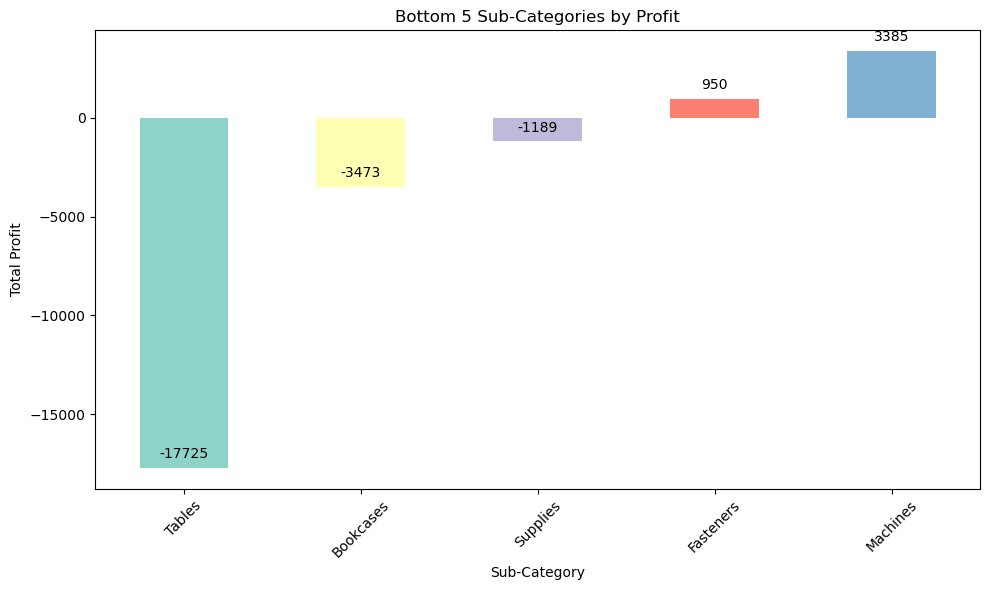

In [48]:
Bottom_5_sub_categories_by_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values(ascending=True).head(5) # Analyze profit by sub-category and sort in ascending order, then select bottom 5
ax =Bottom_5_sub_categories_by_profit.plot(
    kind='bar',
    figsize=(10, 6),
    color=sns.color_palette('Set3', len(Bottom_5_sub_categories_by_profit))
)
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.0f'), #Adding annotations to the bars to show the exact count of orders for each country
                (p.get_x() + p.get_width() / 2., p.get_height()), # Positioning the annotations at the center of each bar
                ha='center', va='center', 
                xytext=(0, 10), 
                textcoords='offset points')
plt.title('Bottom 5 Sub-Categories by Profit') # Set the title of the plot
plt.xlabel('Sub-Category') # Set the x-axis label
plt.ylabel('Total Profit') # Set the y-axis label
plt.xticks(rotation=45) # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent overlap
plt.show() # Display the plot   

### *Scatter Plot of Discount vs Profit*

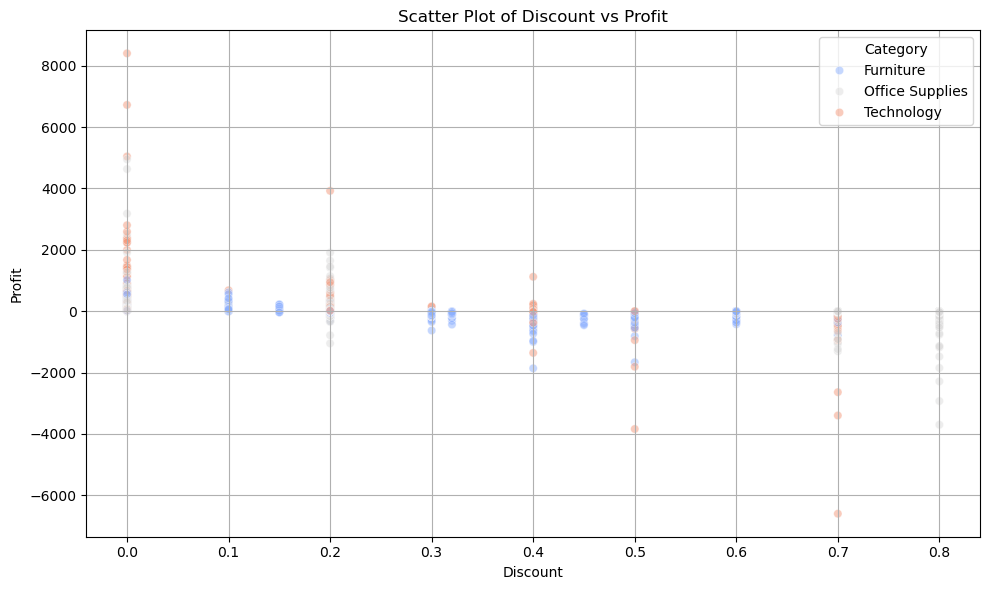

In [ ]:
plt.figure(figsize=(10, 6)) # Set the figure size for the scatter plot
sns.scatterplot(data=df, x='Discount', y='Profit', hue='Category', palette='coolwarm', alpha=0.5) # Create a scatter plot to analyze the relationship between 'Discount' and 'Profit'
plt.title('Scatter Plot of Discount vs Profit') # Set the title of the plot
plt.xlabel('Discount') # Set the x-axis label
plt.ylabel('Profit') # Set the y-axis label
plt.grid(True) # Add a grid for better readability
plt.tight_layout() # Adjust layout to prevent overlap
plt.show() # Display the plot


### *Sales Trend Over Time*

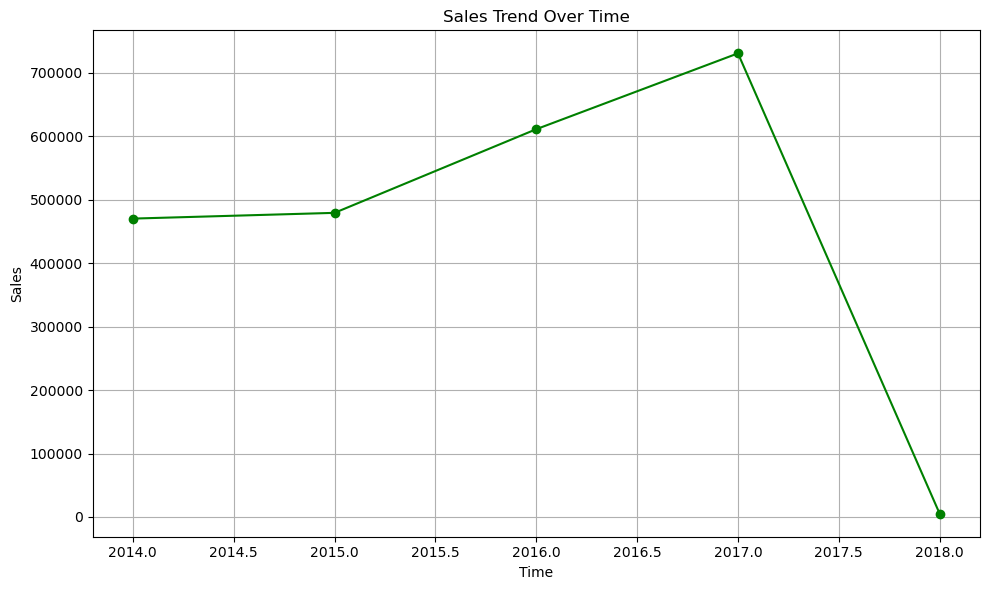

In [31]:
df_yearly_sales = df.groupby(df['Ship Date'].dt.year)['Sales'].sum() # Group sales by year based on 'Ship Date' and calculate the total sales for each year
plt.figure(figsize=(10, 6)) # Set the figure size for the line plot
plt.plot(df_yearly_sales.index, df_yearly_sales.values,color='green', marker='o', linestyle='-') # Create a line plot to visualize sales trends over time 2014-2017
plt.title('Sales Trend Over Time') # Set the title of the plot  
plt.xlabel('Time') # Set the x-axis label
plt.ylabel('Sales') # Set the y-axis label
plt.grid(True) # Add a grid for better readability
plt.tight_layout() # Adjust layout to prevent overlap
plt.show() # Display the plot


## *Thank you for your Considerations!*